# The following notebook is intended to model HUPA003P glucose using a simple nn compose by to layers

In [54]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

Read the data 

In [55]:
data = pd.read_csv('../Data/Preprocessed/HUPA0003P.csv', sep=';')[['time', 'glucose']]
data['time'] = pd.to_datetime(data['time'])

Normalize data 

In [56]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
data['glucose'] = scaler.fit_transform(data['glucose'].values.reshape(-1,1))

In [57]:
data

,time,glucose
0,2018-06-13 21:40:00,0.290890
1,2018-06-13 21:45:00,0.288820
2,2018-06-13 21:50:00,0.286749
3,2018-06-13 21:55:00,0.284679
4,2018-06-13 22:00:00,0.282609
...,...,...
3765,2018-06-26 23:25:00,0.362319
3766,2018-06-26 23:30:00,0.354037
3767,2018-06-26 23:35:00,0.357143
3768,2018-06-26 23:40:00,0.360248


## Architecture 


- input layer (size of window)
- output layer (1)
- activation function : sigmoid 

In [58]:
import torch 
import torch.nn as nn

In [59]:
input_size = 4 ## window size 

In [60]:
class Simple_two_layer(nn.Module):
    def __init__(self, window_size):
        super().__init__()
        self.window_size = window_size
        self.input_layer = nn.Linear(in_features=window_size, out_features=1)
        self.activation_function = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.activation_function(x)
        return x

## Generate data set according to our nn

In [61]:
import sys
sys.path.append("..")
from scripts.window_regressor import Window_Regressor_Sequence_to_scalar

In [62]:
train = Window_Regressor_Sequence_to_scalar(time_series_data=data['glucose'][:-12], window_size=input_size, horizon=1).generate_data_set()
test = Window_Regressor_Sequence_to_scalar(time_series_data=data['glucose'][-12:], window_size=input_size, horizon=1).generate_data_set()

In [63]:
train

,Predictor_0,Predictor_1,Predictor_2,Predictor_3,Target
0,0.290890,0.288820,0.286749,0.284679,0.282609
1,0.288820,0.286749,0.284679,0.282609,0.280538
2,0.286749,0.284679,0.282609,0.280538,0.278468
3,0.284679,0.282609,0.280538,0.278468,0.276398
4,0.282609,0.280538,0.278468,0.276398,0.260870
...,...,...,...,...,...
3749,0.250518,0.271222,0.291925,0.283644,0.275362
3750,0.271222,0.291925,0.283644,0.275362,0.267081
3751,0.291925,0.283644,0.275362,0.267081,0.310559
3752,0.283644,0.275362,0.267081,0.310559,0.354037


In [64]:
test

,Predictor_0,Predictor_1,Predictor_2,Predictor_3,Target
0,0.399586,0.401656,0.403727,0.395445,0.387164
1,0.401656,0.403727,0.395445,0.387164,0.378882
2,0.403727,0.395445,0.387164,0.378882,0.370600
3,0.395445,0.387164,0.378882,0.370600,0.362319
4,0.387164,0.378882,0.370600,0.362319,0.354037
5,0.378882,0.370600,0.362319,0.354037,0.357143
6,0.370600,0.362319,0.354037,0.357143,0.360248
7,0.362319,0.354037,0.357143,0.360248,0.363354


In [65]:
epochs = 1000
model = Simple_two_layer(window_size=input_size)
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)
criterion = nn.MSELoss()

In [66]:
X_train = torch.FloatTensor(train.values[:, :-1])
y_train = torch.FloatTensor(train.values[:, -1])
X_test = torch.FloatTensor(test.values[:, :-1])
y_test = torch.FloatTensor(test.values[:, -1])

In [67]:
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    # Forward pass
    outputs = model.forward(X_train)
    loss = criterion(outputs, y_train)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    total_loss += loss.item()
    train_losses.append(total_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}')

/home/arturom27/.local/lib/python3.13/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([3754])) that is different to the input size (torch.Size([3754, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [50/1000], Loss: 0.0633
Epoch [100/1000], Loss: 0.0597
Epoch [100/1000], Loss: 0.0597
Epoch [150/1000], Loss: 0.0567
Epoch [150/1000], Loss: 0.0567
Epoch [200/1000], Loss: 0.0541
Epoch [200/1000], Loss: 0.0541
Epoch [250/1000], Loss: 0.0520
Epoch [250/1000], Loss: 0.0520
Epoch [300/1000], Loss: 0.0502
Epoch [300/1000], Loss: 0.0502
Epoch [350/1000], Loss: 0.0486
Epoch [350/1000], Loss: 0.0486
Epoch [400/1000], Loss: 0.0473
Epoch [400/1000], Loss: 0.0473
Epoch [450/1000], Loss: 0.0462
Epoch [450/1000], Loss: 0.0462
Epoch [500/1000], Loss: 0.0452
Epoch [500/1000], Loss: 0.0452
Epoch [550/1000], Loss: 0.0444
Epoch [550/1000], Loss: 0.0444
Epoch [600/1000], Loss: 0.0437
Epoch [600/1000], Loss: 0.0437
Epoch [650/1000], Loss: 0.0431
Epoch [650/1000], Loss: 0.0431
Epoch [700/1000], Loss: 0.0426
Epoch [700/1000], Loss: 0.0426
Epoch [750/1000], Loss: 0.0421
Epoch [750/1000], Loss: 0.0421
Epoch [800/1000], Loss: 0.0417
Epoch [800/1000], Loss: 0.0417
Epoch [850/1000], Loss: 0.0414
Epoch [85

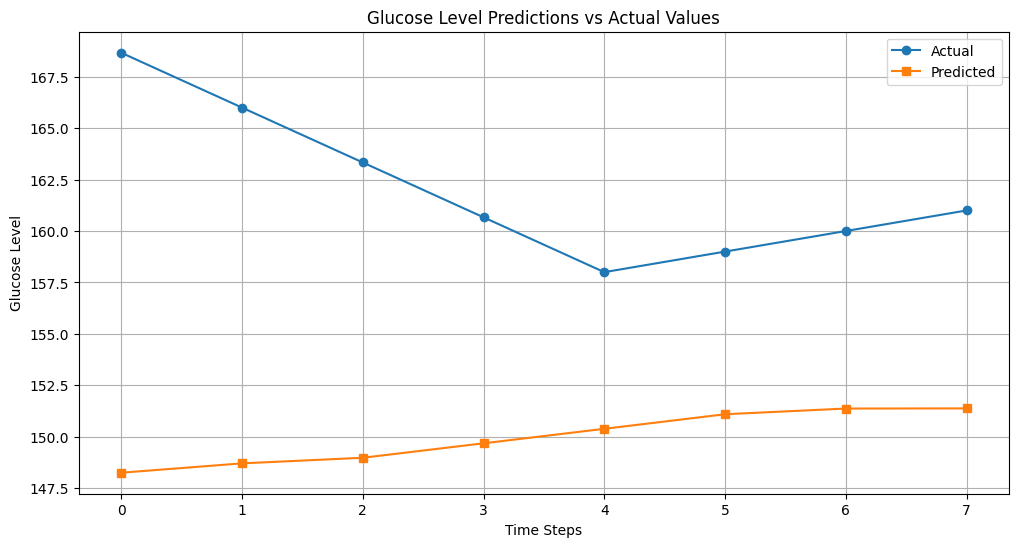

Test MSE: 166.2773
Test RMSE: 12.8949
Test MAE: 12.1030


In [68]:
# Evaluate on test set
model.eval()
with torch.no_grad():
    y_pred = model(X_test).numpy()

# Inverse transform predictions and actual values
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1))

# Plot predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label='Actual', marker='o')
plt.plot(y_pred_original, label='Predicted', marker='s')
plt.title('Glucose Level Predictions vs Actual Values')
plt.xlabel('Time Steps')
plt.ylabel('Glucose Level')
plt.legend()
plt.grid(True)
plt.show()

# Calculate and print metrics
mse = np.mean((y_test_original - y_pred_original) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test_original - y_pred_original))
print(f'Test MSE: {mse:.4f}')
print(f'Test RMSE: {rmse:.4f}')
print(f'Test MAE: {mae:.4f}')